# CNN-001 Energy Regression Diagnosis

Executed diagnostic companion for the 50-epoch CNN-001 regression run. All reported physical-energy errors are in MeV.

## tl;dr

- The best long-run checkpoint (epoch 23) reaches validation R² **0.0530** and RMSE **0.010301 MeV**—only a 2.7% RMSE improvement over predicting the training mean.
- The same raw projections deterministically recover the target by summing pixels: validation R² is approximately **0.99999999** with RMSE near **1e-6 MeV**.
- The failure is therefore structural: the MaxPool/AdaptiveAvg CNN discards additive energy amplitude. Smooth-L1, target standardization, and BF16 are not the primary cause.
- CNN-002 should preserve a global FP32 energy sum, but this also exposes that the current target is derived from the same voxel energies as the input.

## Context & Methods

### Question

Is CNN-001's poor regression caused mainly by its Smooth-L1 objective, or by its network structure?

### Key Assumptions

- The 2026-08-01 run logs and best checkpoint are the authoritative artifacts.
- Validation is replayed on the checkpoint's saved file split and projection configuration.
- `energy_target` is the float64 per-event sum of voxel energies; raw images are scaled by 40.
- The training-mean predictor is the null baseline. The per-view pixel sum is a data-flow baseline, not an independent learned reconstruction.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "pyproject.toml").is_file()
)
sys.path.insert(0, str(ROOT / "src"))

from next_cnn.data import NextIterableDataset, ProjectionConfig, discover_source_files
from next_cnn.model import SimpleNextEnergyRegressor

REGRESSION_LOG = ROOT / "03_training_runs/logs/cnn_001_two_conv_baseline_energy_regression_run2_validation_metrics_20260801_204218.csv"
CLASSIFICATION_LOG = ROOT / "03_training_runs/logs/cnn_001_two_conv_baseline_classification_run2_validation_metrics_20260801_204055.csv"
CHECKPOINT = ROOT / "02_models/checkpoints/NEXTCNN_cnn_001_two_conv_baseline_energy_regression_run2_best.pt"

for artifact in (REGRESSION_LOG, CLASSIFICATION_LOG, CHECKPOINT):
    assert artifact.is_file(), artifact

print(f"Project root: {ROOT}")
print("Source artifacts found: 3/3")
print(f"PyTorch {torch.__version__}; CUDA available: {torch.cuda.is_available()}")

Project root: /home/wenyu/summer
Source artifacts found: 3/3
PyTorch 2.11.0+cu128; CUDA available: True


## Data

### 1. Inspect the complete epoch histories

In [2]:
regression_history = pd.read_csv(REGRESSION_LOG)
classification_history = pd.read_csv(CLASSIFICATION_LOG)
assert len(regression_history) == 50
assert regression_history["epoch"].tolist() == list(range(1, 51))
assert regression_history["projection_coverage"].eq(1.0).all()

best_row = regression_history.loc[regression_history["validation_loss"].idxmin()]
classification_best_auc = classification_history.loc[
    classification_history["validation_auc"].idxmax()
]

pd.DataFrame([
    {
        "artifact": "CNN-001 regression",
        "epochs": len(regression_history),
        "selected_epoch": int(best_row["epoch"]),
        "validation_loss": best_row["validation_loss"],
        "validation_rmse_mev": best_row["validation_energy_rmse_mev"],
        "validation_r2_or_auc": best_row["validation_energy_r2"],
    },
    {
        "artifact": "CNN-001 classification",
        "epochs": len(classification_history),
        "selected_epoch": int(classification_best_auc["epoch"]),
        "validation_loss": classification_best_auc["validation_loss"],
        "validation_rmse_mev": np.nan,
        "validation_r2_or_auc": classification_best_auc["validation_auc"],
    },
]).round(9)

,artifact,epochs,selected_epoch,validation_loss,validation_rmse_mev,validation_r2_or_auc
0,CNN-001 regression,50,23,0.417752,0.010301,0.053001
1,CNN-001 classification,50,50,0.406522,NaN,0.898918


### 2. Reconstruct the saved validation population

In [3]:
checkpoint = torch.load(CHECKPOINT, map_location="cpu", weights_only=False)
assert checkpoint["epoch"] == int(best_row["epoch"]) == 23
normalizer = checkpoint["energy_target_config"]["normalizer"]
energy_mean = float(normalizer["mean"])
energy_std = float(normalizer["std"])
projection = ProjectionConfig.from_dict(checkpoint["projection_config"])

data_options = {
    "root": checkpoint["training_config"]["data"]["root"],
    "split_seed": checkpoint["split_config"]["seed"],
    "split_fractions": checkpoint["split_config"]["fractions"],
    "max_files_per_class": checkpoint["training_config"]["data"]["max_files_per_class"],
}
validation_files = discover_source_files(split="validation", **data_options)
assert [item.group_id for item in validation_files] == checkpoint["data_selection"]["validation_groups"]

validation_dataset = NextIterableDataset(
    validation_files,
    projection=projection,
    shuffle_files=False,
    balance_classes=False,
    seed=42,
)
validation_loader = torch.utils.data.DataLoader(
    validation_dataset,
    batch_size=128,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print({
    "validation_files": len(validation_files),
    "input_scale": projection.input_scale,
    "normalize_energy": projection.normalize_energy,
    "training_target_mean_mev": energy_mean,
    "training_target_std_mev": energy_std,
})

{'validation_files': 200, 'input_scale': 40.0, 'normalize_energy': False, 'training_target_mean_mev': 2.453058454485458, 'training_target_std_mev': 0.010500111591823234}


## Results

### 3. Replay CNN-001 and recompute independent baselines

In [4]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = SimpleNextEnergyRegressor(**checkpoint["model_config"]).to(device)
model.load_state_dict(checkpoint["model_state_dict"], strict=True)
model.eval()

all_targets, all_predictions, all_pixel_sums = [], [], []
all_labels, all_coverages = [], []
probe_images = None

with torch.inference_mode():
    for batch in validation_loader:
        images_cpu = batch["image"]
        images = images_cpu.to(device, non_blocking=True)
        with torch.amp.autocast(
            device_type=device.type,
            dtype=torch.bfloat16 if device.type == "cuda" else torch.float32,
            enabled=device.type == "cuda",
        ):
            standardized_prediction = model(images)
        physical_prediction = energy_mean + energy_std * standardized_prediction.float()
        all_targets.append(batch["energy_target"].numpy())
        all_predictions.append(physical_prediction.cpu().numpy())
        all_pixel_sums.append(images_cpu.double().sum(dim=(-2, -1)).numpy())
        all_labels.append(batch["label"].numpy())
        all_coverages.append(batch["projection_coverage"].numpy())
        if probe_images is None:
            probe_images = images_cpu[:64].clone()

target = np.concatenate(all_targets).astype(np.float64)
prediction = np.concatenate(all_predictions).astype(np.float64)
view_sums = np.concatenate(all_pixel_sums).astype(np.float64)
labels = np.concatenate(all_labels).astype(int)
coverage = np.concatenate(all_coverages).astype(np.float64)
direct_sum_prediction = view_sums.mean(axis=1) / projection.input_scale
constant_prediction = np.full_like(target, energy_mean)

def metrics(name, values):
    error = values - target
    denominator = np.sum((target - target.mean()) ** 2)
    return {
        "predictor": name,
        "mae_mev": np.mean(np.abs(error)),
        "rmse_mev": np.sqrt(np.mean(error ** 2)),
        "bias_mev": np.mean(error),
        "r2": 1.0 - np.sum(error ** 2) / denominator,
        "prediction_std_mev": np.std(values),
    }

comparison = pd.DataFrame([
    metrics("Training-mean constant", constant_prediction),
    metrics("CNN-001 best checkpoint", prediction),
    metrics("Direct mean of 3 view sums", direct_sum_prediction),
])

assert len(target) == 16786
assert np.allclose(coverage, 1.0)
print(comparison.to_string(index=False, float_format=lambda value: f'{value:.12g}'))
comparison

                 predictor           mae_mev          rmse_mev           bias_mev                 r2  prediction_std_mev
    Training-mean constant   0.0086539636245   0.0105865943996 -0.000163594002493 -0.000238850374264                   0
   CNN-001 best checkpoint  0.00833224798637   0.0103009947385  -0.00070455260597    0.0530010426501    0.00223713218003
Direct mean of 3 view sums 1.00680040344e-06 1.18117852386e-06  -1.0064471289e-06     0.999999987548     0.0105852707442


,predictor,mae_mev,rmse_mev,bias_mev,r2,prediction_std_mev
0,Training-mean constant,0.008654,0.010587,-0.000164,-0.000239,0.000000
1,CNN-001 best checkpoint,0.008332,0.010301,-0.000705,0.053001,0.002237
2,Direct mean of 3 view sums,0.000001,0.000001,-0.000001,1.000000,0.010585


### 4. Quantify collapse, loss behavior, and scale sensitivity

In [5]:
error_standardized = (prediction - target) / energy_std
smooth_l1 = np.where(
    np.abs(error_standardized) < 1.0,
    0.5 * error_standardized**2,
    np.abs(error_standardized) - 0.5,
)
calibration_slope, calibration_intercept = np.polyfit(target, prediction, 1)
pearson = np.corrcoef(target, prediction)[0, 1]

probe_images = probe_images.to(device)
with torch.inference_mode():
    def physical_inference(images):
        with torch.amp.autocast(
            device_type=device.type,
            dtype=torch.bfloat16 if device.type == "cuda" else torch.float32,
            enabled=device.type == "cuda",
        ):
            z_value = model(images)
        return (energy_mean + energy_std * z_value.float()).cpu().numpy()

    probe_base = physical_inference(probe_images)
    probe_scaled = physical_inference(probe_images * 1.005)
scale_response = np.mean(
    (probe_scaled - probe_base) / (0.005 * target[: len(probe_base)])
)

class_diagnostics = []
for class_label in (0, 1):
    mask = labels == class_label
    class_diagnostics.append({
        "class_label": class_label,
        "events": int(mask.sum()),
        "within_class_pearson": np.corrcoef(target[mask], prediction[mask])[0, 1],
        "target_std_mev": np.std(target[mask]),
        "prediction_std_mev": np.std(prediction[mask]),
    })

diagnostics = pd.Series({
    "events": len(target),
    "projection_coverage_min": coverage.min(),
    "projection_coverage_max": coverage.max(),
    "cnn_prediction_to_target_std_ratio": np.std(prediction) / np.std(target),
    "cnn_pearson": pearson,
    "cnn_calibration_slope": calibration_slope,
    "cnn_smooth_l1_replay": smooth_l1.mean(),
    "fraction_abs_standardized_error_gt_1": np.mean(np.abs(error_standardized) > 1),
    "mse_standardized": np.mean(error_standardized**2),
    "mean_scale_response_ideal_1": scale_response,
})

print(diagnostics.round(9).to_string())
pd.DataFrame(class_diagnostics).round(6)

events                                  16786.000000
projection_coverage_min                     1.000000
projection_coverage_max                     1.000000
cnn_prediction_to_target_std_ratio          0.211343
cnn_pearson                                 0.241544
cnn_calibration_slope                       0.051048
cnn_smooth_l1_replay                        0.417752
fraction_abs_standardized_error_gt_1        0.322114
mse_standardized                            0.962433
mean_scale_response_ideal_1                 0.007432


,class_label,events,within_class_pearson,target_std_mev,prediction_std_mev
0,0,10246,0.044499,0.00990,0.001967
1,1,6540,0.042923,0.00991,0.001516


### 5. Visual checks

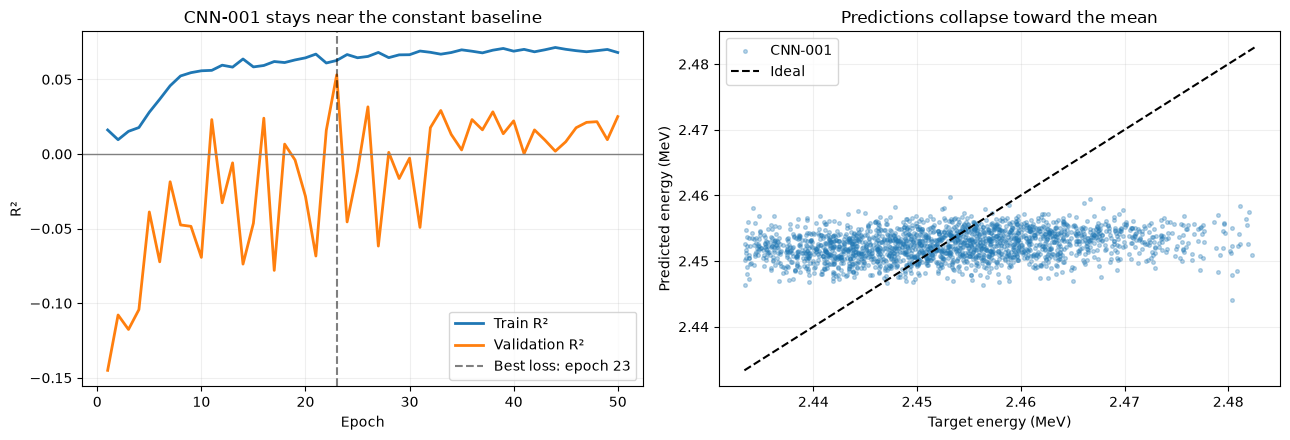

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(
    regression_history["epoch"],
    regression_history["train_energy_r2"],
    label="Train R²",
    linewidth=2,
)
axes[0].plot(
    regression_history["epoch"],
    regression_history["validation_energy_r2"],
    label="Validation R²",
    linewidth=2,
)
axes[0].axvline(23, color="black", linestyle="--", alpha=0.5, label="Best loss: epoch 23")
axes[0].axhline(0, color="gray", linewidth=1)
axes[0].set(title="CNN-001 stays near the constant baseline", xlabel="Epoch", ylabel="R²")
axes[0].legend()
axes[0].grid(alpha=0.2)

sample_index = np.linspace(0, len(target) - 1, 2000, dtype=int)
axes[1].scatter(target[sample_index], prediction[sample_index], s=7, alpha=0.3, label="CNN-001")
axes[1].plot([target.min(), target.max()], [target.min(), target.max()], color="black", linestyle="--", label="Ideal")
axes[1].set(
    title="Predictions collapse toward the mean",
    xlabel="Target energy (MeV)",
    ylabel="Predicted energy (MeV)",
)
axes[1].legend()
axes[1].grid(alpha=0.2)
fig.tight_layout()
plt.show()

## Takeaways

1. **Primary cause: architecture.** CNN-001 reaches only R² 0.053 while its prediction standard deviation is about 21% of the target standard deviation. Train R² is also low, so this is severe underfitting rather than a large generalization gap.
2. **Smooth-L1 is not the blocker.** The direct pixel-sum baseline attains essentially perfect R² under the same target and scaling. MSE could weight large errors more strongly, but it cannot restore a signal discarded by pooling.
3. **The topology branch learned the wrong invariant for regression.** Classification reaches validation AUC about 0.899, while within-class energy correlations remain near zero. MaxPool plus AdaptiveAvgPool is useful for morphology but not additive mass.
4. **Recommended implementation:** preserve CNN-001 for reproducibility and add CNN-002 with an FP32 global view-sum skip in both classification and regression programs.
5. **Scientific caveat:** the current target and raw input are built from the same voxel energies. Explicit summation is the correct conservation baseline, but a non-trivial reconstruction study requires detector-response/noisy inputs and an independent truth target.